In [63]:
import sys, os, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import functions2 as f2
import fx_hedges.fxshort_gates
import yfinance as yf
importlib.reload(fx_hedges.fxshort_gates)
importlib.reload(f2)

<module 'functions2' from '/Users/alexwebb/laptop_coding/risk_matrix/functions2.py'>

In [ ]:
ticker = 'ULVR.LSE'
s = f2.get_series(ticker, window_start='2018-01-01', window_end='2020-01-01')
print(s.head())

In [67]:
import pandas as pd

url = "https://stooq.com/q/d/l/?s=ulvr.uk&d1=20180101&d2=20260307&i=d"
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')
print(df.head())


               Open     High      Low    Close   Volume
Date                                                   
2018-01-02  3362.07  3362.07  3293.15  3298.88  2330153
2018-01-03  3296.42  3316.43  3267.86  3309.87  1861881
2018-01-04  3311.09  3328.64  3296.83  3320.08  5815023
2018-01-05  3289.92  3337.62  3289.92  3337.62  3765005
2018-01-08  3325.77  3346.15  3318.84  3336.80  2497448


In [ ]:
position = 1000
trim_pct = 0.10
take_profit_pct = 0.10

entry_price = s.iloc[0]
initial_position = position
initial_value = (entry_price * position) / 100

print('entry date', s.index[0].date(), 'at price', f"{entry_price:.2f}")
print(f"Position: {position} shares")
print(f"Initial position value: {initial_value:.0f}")


#  Loop through series and apply take-profit logic
total_cash = 0.0  # gross sale proceeds
tot_realized_pnl = 0.0
pnl_snapshots = []
trim_dates = []
trim_date = None

last_price = entry_price
low = entry_price
print('----LOOP-----')
for date, price in s.items():
    if price < low:
        print('-----new low', price)
    low = min(price, low)
    if (price / low - 1) > take_profit_pct:
        # print('=' * 20)
        print(f"/////// Take profit on {date.date()} at price {price:.2f}")
        trim_date = date
        # last_price = price
        print('trim_date set to:', trim_date.date())

        low = price  # reset low after take-profit trigger
        print('+++++low reset to:', low)

        # PnL before trim on full current position
        pnl_before = ((price - entry_price) * position) / 100
        # print(f"Value before trim: {(price * position) / 100:.0f}")
        # print(f"PnL before trim ({position:.0f} sh): {pnl_before:.0f}")
        # print('.......')

        # Trim a fraction of current shares
        shares_to_trim = position * trim_pct
        this_pnl = ((price - entry_price) * shares_to_trim) / 100
        tot_realized_pnl += this_pnl
        cash = (price * shares_to_trim) / 100
        total_cash += cash
        position -= shares_to_trim

        unrealized_pnl = ((price - entry_price) * position) / 100
        total_pnl = tot_realized_pnl + unrealized_pnl

        trim_dates.append((trim_date, price, this_pnl))

        print(f"Trimmed shares: {shares_to_trim:.0f} leaves {position:.0f}")
        print(f"Cash (sale proceeds): {cash:.0f}")
        print(f"PnL from trimmed shares: {this_pnl:.0f}")
        print(f"Total Realized PnL: {tot_realized_pnl:.0f}")
        print(f"Unrealized PnL: {unrealized_pnl:.0f}")
        # print(f"Total PnL after trim: {total_pnl:.0f}")
        print('value after trim:', round((price * position) / 100))

        # break
print('=======END=======')
if trim_date is None:
    print('No take-profit trigger hit in sample window.')
for d in trim_dates:
    print('Trim date:', d[0].date(), 'at price', f"{d[1]:.2f}")
print('total_cash from trims:', round(total_cash))
nav_after_trims = total_cash + (s.iloc[-1] * position) / 100
nav_without_trims = (s.iloc[-1] * initial_position) / 100
trim_pnl = nav_after_trims - nav_without_trims
print('final NAV after trimming: ', round(nav_after_trims))
print('final NAV without trimming: ', round(nav_without_trims))
print('PnL from trims:', round(trim_pnl))


entry date 2019-05-16 at price 4546.74
Position: 1000 shares
Initial position value: 45467
----LOOP-----
-----new low 4523.886
/////// Take profit on 2019-09-02 at price 5019.03
trim_date set to: 2019-09-02
+++++low reset to: 5019.0282
Trimmed shares: 100 leaves 900
Cash (sale proceeds): 5019
PnL from trimmed shares: 472
Total Realized PnL: 472
Unrealized PnL: 4251
value after trim: 45171
-----new low 4931.4261
-----new low 4820.9713
-----new low 4716.7058
-----new low 4675.7613
-----new low 4617.6774
-----new low 4565.7826
-----new low 4556.7368
-----new low 4555.3085
-----new low 4551.0236
-----new low 4424.8575
-----new low 4422.9532
-----new low 4350.1101
-----new low 4340.112
-----new low 4339.6359
-----new low 4310.1179
-----new low 4280.1237
-----new low 4261.0797
-----new low 4093.4931
-----new low 4073.9731
-----new low 4037.3135
/////// Take profit on 2020-02-06 at price 4471.04
trim_date set to: 2020-02-06
+++++low reset to: 4471.0391
Trimmed shares: 90 leaves 810
Cash (sale

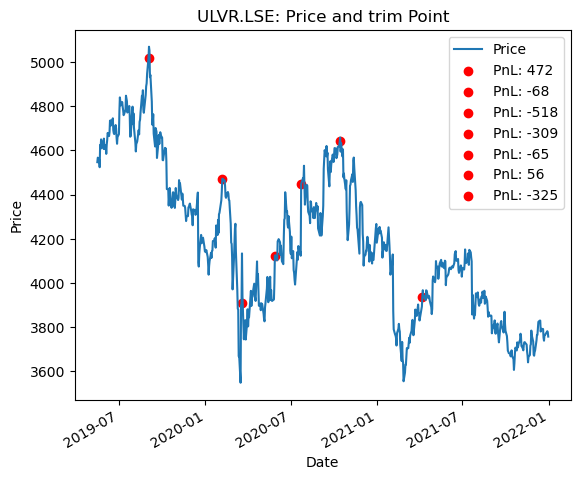

In [58]:
import matplotlib.dates as mdates
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha='right')
plt.tight_layout
plt.plot(s.index, s.values, label='Price')
for t in trim_dates:
    plt.scatter([t[0]], s.loc[t[0]], color='red', label=f"PnL: {t[2]:.0f}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"{ticker}: Price and trim Point")
plt.legend()
plt.show()
